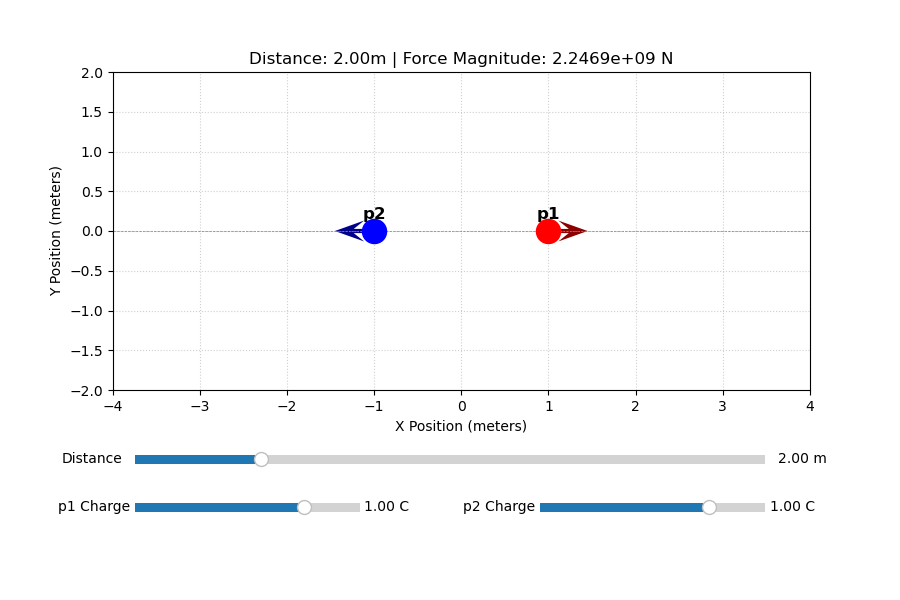

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

class ChargedParticle():
    def __init__(self, charge: float, mass: float, position: np.ndarray, velocity: np.ndarray | None = None):
        self.charge: float = charge
        self.mass: float = mass
        self.position: np.ndarray = position
        self.velocity: np.ndarray = velocity if velocity is not None else np.zeros_like(position)

class CoulombsLaw:
    COULOMB_CONSTANT: float = 8.9875517923e9

    @staticmethod
    def calculate_forces(p1: ChargedParticle, p2: ChargedParticle) -> tuple[np.ndarray, np.ndarray]:
        displacement = p1.position - p2.position
        distance = np.linalg.norm(displacement)
        
        if distance == 0.0:
            return np.zeros_like(p1.position), np.zeros_like(p2.position)
            
        force_magnitude = (CoulombsLaw.COULOMB_CONSTANT * p1.charge * p2.charge) / (distance ** 2)
        unit_vector = displacement / distance
        force_on_p1 = force_magnitude * unit_vector
        force_on_p2 = -force_on_p1
        
        return force_on_p1, force_on_p2

# --- Initializing System Elements ---
particle1 = ChargedParticle(charge=1.0, mass=1.0, position=np.array([1.0, 0.0]))
particle2 = ChargedParticle(charge=1.0, mass=1.0, position=np.array([-1.0, 0.0]))

fig, ax = plt.subplots(figsize=(9, 6))
plt.subplots_adjust(bottom=0.35)

# Setup UI Sliders first so they remain constant outside the dynamic plotting area
ax_dist = plt.axes([0.15, 0.22, 0.70, 0.03])
ax_p1_q = plt.axes([0.15, 0.14, 0.25, 0.03])
ax_p2_q = plt.axes([0.60, 0.14, 0.25, 0.03])

slider_dist = Slider(ax_dist, 'Distance', 1.0, 6.0, valinit=2.0, valfmt='%1.2f m')
slider_p1_q = Slider(ax_p1_q, 'p1 Charge', -2.0, 2.0, valinit=1.0, valfmt='%1.2f C')
slider_p2_q = Slider(ax_p2_q, 'p2 Charge', -2.0, 2.0, valinit=1.0, valfmt='%1.2f C')

# Global reference list to prevent Python's garbage collector from locking up the UI
slider_references = [slider_dist, slider_p1_q, slider_p2_q]

# --- Interactive Update Callback (Now with Full Background Refresh) ---
def update(val):
    # 1. Clear the old vector and background layers completely
    ax.cla()
    
    # 2. Extract active slider parameters
    current_distance = slider_dist.val
    particle1.charge = slider_p1_q.val
    particle2.charge = slider_p2_q.val

    # 3. Calculate spatial symmetry positions
    half_dist = current_distance / 2.0
    particle1.position = np.array([half_dist, 0.0])
    particle2.position = np.array([-half_dist, 0.0])

    # 4. Compute Electrostatic forces
    f1, f2 = CoulombsLaw.calculate_forces(particle1, particle2)
    f1_size = np.linalg.norm(f1)
    
    # Define color mappings based on particle polarities
    p1_color = 'red' if particle1.charge >= 0 else 'cyan'
    p2_color = 'blue' if particle2.charge >= 0 else 'purple'

    # 5. Redraw the clean, fresh background structure
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim([-4.0, 4.0])
    ax.set_ylim([-2.0, 2.0])
    ax.set_xlabel('X Position (meters)')
    ax.set_ylabel('Y Position (meters)')
    ax.set_title(f"Distance: {current_distance:.2f}m | Force Magnitude: {f1_size:.4e} N")

    # 6. Re-plot the fresh particles on the cleared slate
    ax.scatter(particle1.position[0], particle1.position[1], color=p1_color, s=300, zorder=5)
    ax.scatter(particle2.position[0], particle2.position[1], color=p2_color, s=300, zorder=5)

    ax.text(particle1.position[0], particle1.position[1] + 0.15, 'p1', fontsize=12, fontweight='bold', ha='center')
    ax.text(particle2.position[0], particle2.position[1] + 0.15, 'p2', fontsize=12, fontweight='bold', ha='center')

    # 7. Redraw sleek arrows with a fixed structural scale width mapping
    FORCE_SCALE = 5e9
    ax.quiver(particle1.position[0], particle1.position[1], f1[0], f1[1], 
              angles='xy', scale_units='xy', scale=FORCE_SCALE, 
              color='darkred', width=0.006, headwidth=5, headlength=7)
    
    ax.quiver(particle2.position[0], particle2.position[1], f2[0], f2[1], 
              angles='xy', scale_units='xy', scale=FORCE_SCALE, 
              color='darkblue', width=0.006, headwidth=5, headlength=7)

    # Force draw update to UI canvas
    fig.canvas.draw_idle()

# Bind listeners to the refresh callback
slider_dist.on_changed(update)
slider_p1_q.on_changed(update)
slider_p2_q.on_changed(update)

# Draw the initial frame
update(None)
plt.show()


In [26]:
# Ensure ChargedParticle and CoulombManyBody are compiled in your notebook session history
import numpy as np
import plotly.graph_objects as go
from ipywidgets import FloatSlider, BoundedFloatText, HBox, VBox, Label, HTML, jslink

# 1. Initialize physical data structures
p1 = ChargedParticle(charge=1.0e-9, mass=1.0, position=np.array([1.0, 0.0], dtype=float))
p2 = ChargedParticle(charge=1.0e-9, mass=1.0, position=np.array([-1.0, 0.0], dtype=float))
p3 = ChargedParticle(charge=-1.0e-9, mass=1.0, position=np.array([0.0, 1.0], dtype=float))

system = CoulombManyBody([p1, p2, p3])

# 2. Build Interactive Plotly Figure Canvas
fig = go.FigureWidget()

fig.update_layout(
    title={"text": "Three-Body Vector Sandbox", "font": {"size": 14, "weight": "bold"}},
    xaxis=dict(range=[-4, 4], zeroline=True, zerolinewidth=1, zerolinecolor='gray', title="X Position (m)"),
    yaxis=dict(range=[-4, 4], zeroline=True, zerolinewidth=1, zerolinecolor='gray', title="Y Position (m)", scaleanchor="x", scaleratio=1),
    width=600, height=440,  # Adjusted width slightly to balance the right-hand panel space
    showlegend=False,
    margin=dict(l=40, r=40, t=50, b=40),
    template="plotly_white"
)

# Trace 0: Tracks the circular particle dots
fig.add_trace(go.Scatter(x=[], y=[], mode='markers+text', text=[], textposition="top center", marker=dict(size=18, color=[])))

# NEW: Create a dedicated HTML side-panel widget for displaying vectors
force_panel = HTML(
    value="",
    layout={'margin': '20px 0 0 20px', 'padding': '15px', 'border': '1px solid #ccc', 'border_radius': '5px', 'width': '280px', 'background_color': '#f9f9f9'}
)

# 3. Helper Function to build controls cleanly: Label -> Text Box -> Slider
def create_clean_control(var_name, min_v, max_v, init_v):
    name_label = Label(value=var_name, layout={'width': '65px'})
    text_box = BoundedFloatText(value=init_v, min=min_v, max=max_v, step=0.1, layout={'width': '65px'})
    slider = FloatSlider(value=init_v, min=min_v, max=max_v, step=0.1, description='', continuous_update=True, layout={'width': '140px'})
    
    jslink((text_box, 'value'), (slider, 'value'))
    
    control_strip = HBox([name_label, text_box, slider])
    return slider, control_strip

s_p1_x, strip_p1_x = create_clean_control('p1 X (m)', -3.0, 3.0, 1.0)
s_p1_y, strip_p1_y = create_clean_control('p1 Y (m)', -3.0, 3.0, 0.0)
s_p1_q, strip_p1_q = create_clean_control('p1 Q (nC)', -2.0, 2.0, 1.0)

s_p2_x, strip_p2_x = create_clean_control('p2 X (m)', -3.0, 3.0, -1.0)
s_p2_y, strip_p2_y = create_clean_control('p2 Y (m)', -3.0, 3.0, 0.0)
s_p2_q, strip_p2_q = create_clean_control('p2 Q (nC)', -2.0, 2.0, 1.0)

s_p3_x, strip_p3_x = create_clean_control('p3 X (m)', -3.0, 3.0, 0.0)
s_p3_y, strip_p3_y = create_clean_control('p3 Y (m)', -3.0, 3.0, 1.0)
s_p3_q, strip_p3_q = create_clean_control('p3 Q (nC)', -2.0, 2.0, -1.0)

# 4. Core Render Function
def update_physics_display(change=None):
    p1.position = np.array([float(s_p1_x.value), float(s_p1_y.value)])
    p1.charge = float(s_p1_q.value) * 1e-9
    p2.position = np.array([float(s_p2_x.value), float(s_p2_y.value)])
    p2.charge = float(s_p2_q.value) * 1e-9
    p3.position = np.array([float(s_p3_x.value), float(s_p3_y.value)])
    p3.charge = float(s_p3_q.value) * 1e-9

    forces = system.calculate_all_net_forces()
    f1, f2, f3 = forces[0], forces[1], forces[2]
    
    # NEW: Calculate the vector sum of all forces in the system
    total_system_force = f1 + f2 + f3

    # Target Update 1: Update the scatter particle states
    x_coords = [float(p1.position[0]), float(p2.position[0]), float(p3.position[0])]
    y_coords = [float(p1.position[1]), float(p2.position[1]), float(p3.position[1])]
    labels = [f"p1 ({s_p1_q.value:.1f} nC)", f"p2 ({s_p2_q.value:.1f} nC)", f"p3 ({s_p3_q.value:.1f} nC)"]
    colors = ['red' if s_p1_q.value >= 0 else 'cyan', 'blue' if s_p2_q.value >= 0 else 'green', 'purple' if s_p3_q.value >= 0 else 'orange']

    fig.data[0].x = x_coords
    fig.data[0].y = y_coords
    fig.data[0].text = labels
    fig.data[0].marker.color = colors

    # Target Update 2: Vector Arrow Annotation generation
    ARROW_VISUAL_SCALE = 1e9  
    new_vector_annotations = []

    for p, f in zip(system.particles, forces):
        x_start, y_start = float(p.position[0]), float(p.position[1])
        x_end = x_start + float(f[0]) * ARROW_VISUAL_SCALE
        y_end = y_start + float(f[1]) * ARROW_VISUAL_SCALE
        
        if np.linalg.norm(f) < 1e-12:
            continue
            
        new_vector_annotations.append(dict(
            x=x_end, y=y_end, ax=x_start, ay=y_start,
            xref='x', yref='y', axref='x', ayref='y',      
            showarrow=True, arrowhead=2, arrowsize=1.2, arrowwidth=2.5, arrowcolor='black', text=""                    
        ))

    fig.layout.annotations = new_vector_annotations

    # NEW: Update the HTML panel with formatted monospace text
    force_panel.value = f"""
    <div style="font-family: monospace; line-height: 1.5;">
        <h4 style="margin-top: 0; color: #333; font-family: sans-serif;">📊 Net Force Vectors (N)</h4>
        <p><b style="color: red;">F₁</b> = [{f1[0]:.2e}, {f1[1]:.2e}]</p>
        <p><b style="color: blue;">F₂</b> = [{f2[0]:.2e}, {f2[1]:.2e}]</p>
        <p><b style="color: purple;">F₃</b> = [{f3[0]:.2e}, {f3[1]:.2e}]</p>
        <hr style="border: 0; border-top: 1px dashed #bbb;">
        <p><b>Σ F_net</b> = [{total_system_force[0]:.2e}, {total_system_force[1]:.2e}]</p>
        <small style="color: #666; font-size: 10px;">(Should equal 0 via Newton's 3rd Law)</small>
    </div>
    """

# 5. Bind observers manually
sliders_to_watch = [s_p1_x, s_p1_y, s_p1_q, s_p2_x, s_p2_y, s_p2_q, s_p3_x, s_p3_y, s_p3_q]
for s in sliders_to_watch:
    s.observe(update_physics_display, names='value')

# 6. Assemble Layout: Graph and HTML panel sit side-by-side, sliders go underneath
graph_and_readout = HBox([fig, force_panel], layout={'align_items': 'flex-start'})

ui_controls = HBox([
    VBox([Label(value="⚡ PARTICLE 1", layout={'margin': '0 0 10px 0'}), strip_p1_x, strip_p1_y, strip_p1_q], layout={'border': '1px solid #ddd', 'padding': '10px', 'margin': '5px'}),
    VBox([Label(value="⚡ PARTICLE 2", layout={'margin': '0 0 10px 0'}), strip_p2_x, strip_p2_y, strip_p2_q], layout={'border': '1px solid #ddd', 'padding': '10px', 'margin': '5px'}),
    VBox([Label(value="⚡ PARTICLE 3", layout={'margin': '0 0 10px 0'}), strip_p3_x, strip_p3_y, strip_p3_q], layout={'border': '1px solid #ddd', 'padding': '10px', 'margin': '5px'})
])

# Initialize the layout and launch
update_physics_display()
display(VBox([graph_and_readout, ui_controls]))


    'data': [{'marker': {'color': ['red', 'blue', 'orange'], 'siz…